<a href="https://colab.research.google.com/github/2023atharvvichare/Machine-Learning/blob/main/Expectation_Maximization_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal


In [9]:
np.random.seed(50)


In [10]:
mean1 = np.array([0, 0])
cov1 = np.array([[1, 0.5], [0.5, 1]])


In [11]:

mean2 = np.array([5, 5])
cov2 = np.array([[1, -0.3], [-0.3, 1]])



In [12]:

X1 = np.random.multivariate_normal(mean1, cov1, 200)
X2 = np.random.multivariate_normal(mean2, cov2, 200)
X = np.vstack((X1, X2))
np.random.shuffle(X)



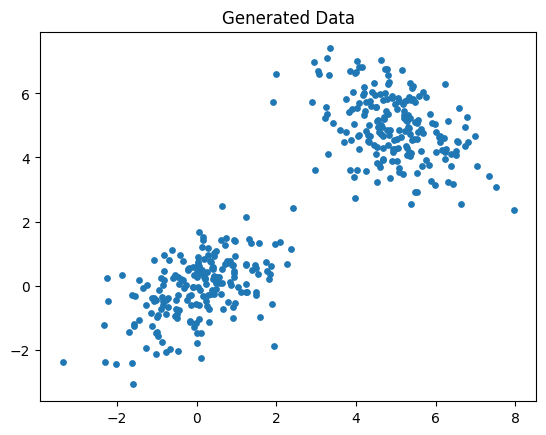

In [13]:
plt.scatter(X[:, 0], X[:, 1], s=15)
plt.title("Generated Data")
plt.show()


In [14]:
K = 2
N, D = X.shape


In [15]:


means = X[np.random.choice(N, K, False)]
covariances = [np.eye(D) for _ in range(K)]
weights = np.ones(K) / K


In [16]:

def gaussian_pdf(x, mean, cov):
    return multivariate_normal.pdf(x, mean=mean, cov=cov)


In [17]:
def em_gmm(X, K, max_iters=100, tol=1e-4):
    N, D = X.shape
    np.random.seed(42)

    means = X[np.random.choice(N, K, False)]
    covariances = [np.eye(D) for _ in range(K)]
    weights = np.ones(K) / K

    log_likelihoods = []

    for iteration in range(max_iters):
        responsibilities = np.zeros((N, K))
        for k in range(K):
            responsibilities[:, k] = weights[k] * gaussian_pdf(X, means[k], covariances[k])

        responsibilities /= responsibilities.sum(axis=1, keepdims=True)

        N_k = responsibilities.sum(axis=0)
        for k in range(K):
            means[k] = (1 / N_k[k]) * np.sum(responsibilities[:, k, None] * X, axis=0)
            diff = X - means[k]
            covariances[k] = (1 / N_k[k]) * np.dot((responsibilities[:, k, None] * diff).T, diff)
            weights[k] = N_k[k] / N

        ll = np.sum(np.log(np.sum([
            weights[k] * gaussian_pdf(X, means[k], covariances[k]) for k in range(K)
        ], axis=0)))
        log_likelihoods.append(ll)

        if iteration > 1 and abs(ll - log_likelihoods[-2]) < tol:
            break

    return means, covariances, weights, responsibilities, log_likelihoods


In [18]:
means, covs, weights, resp, lls = em_gmm(X, K=2)
print("Means:\n", means)
print("\nWeights:\n", weights)


Means:
 [[ 0.04699493 -0.05380493]
 [ 4.96145444  4.95244775]]

Weights:
 [0.50021564 0.49978436]


In [19]:
cluster_assignments = np.argmax(resp, axis=1)



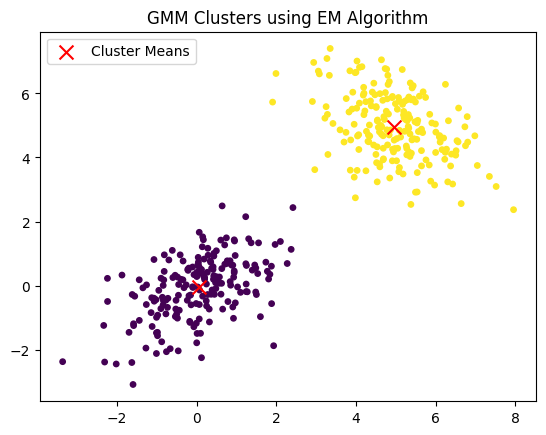

In [20]:
plt.scatter(X[:, 0], X[:, 1], c=cluster_assignments, cmap='viridis', s=15)
plt.scatter(means[:, 0], means[:, 1], c='red', marker='x', s=100, label='Cluster Means')
plt.title("GMM Clusters using EM Algorithm")
plt.legend()
plt.show()

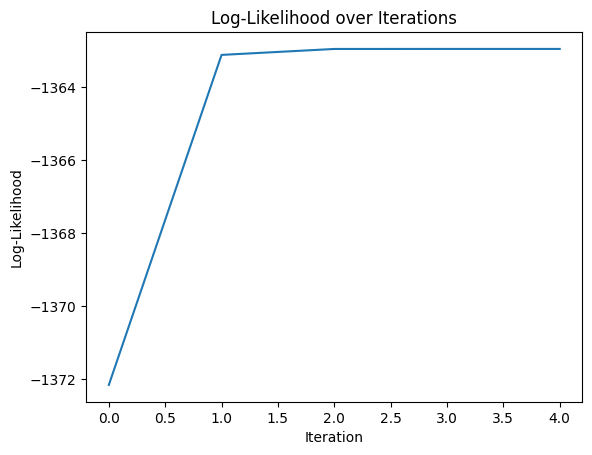

In [21]:
plt.plot(lls)
plt.title("Log-Likelihood over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.show()
